# Приступим к работе...  

### Генетический алгоритм  

**Генетический алгоритм** (англ. genetic algorithm) - это некий эвристический алгоритм поиска, используемый для решения задач оптимизации и моделирования путём случайного подбора, комбинирования и вариации искомых параметров с использованием механизмов, аналогичных естественному отбору в природе. Используется данный алгоритм там, где не эффективно применять традиционные методы. В случае с большим пространством поиска, нелинейностью и дискретностью.

##### Постановка задачи лабораторной работы  
Пока что самое интересное применение генетического алгоритма я вижу в маршрутизации между странами или городами. После долгих раздумий было принято решение поработать с задачей оптимизации в нахождении кратчайшего маршрута (пути) между городами с помощью генетического алгоритма


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# Загружаем данные
df = pd.read_csv('.//static//GA_csv//city.csv')
print(df.columns)

Index(['address', 'postal_code', 'country', 'federal_district', 'region_type',
       'region', 'area_type', 'area', 'city_type', 'city', 'settlement_type',
       'settlement', 'kladr_id', 'fias_id', 'fias_level', 'capital_marker',
       'okato', 'oktmo', 'tax_office', 'timezone', 'geo_lat', 'geo_lon',
       'population', 'foundation_year'],
      dtype='object')


In [80]:
print("Список городов:")
df.head()

Список городов:


,address,postal_code,country,federal_district,region_type,region,area_type,area,city_type,city,...,fias_level,capital_marker,okato,oktmo,tax_office,timezone,geo_lat,geo_lon,population,foundation_year
0,"Респ Адыгея, г Адыгейск",385200.0,Россия,Южный,Респ,Адыгея,NaN,NaN,г,Адыгейск,...,4,0,79403000000,79703000001,107,UTC+3,44.878414,39.190289,12689,1969
1,г Майкоп,385000.0,Россия,Южный,Респ,Адыгея,NaN,NaN,г,Майкоп,...,4,2,79401000000,79701000001,105,UTC+3,44.609827,40.100661,144055,1857
2,г Горно-Алтайск,649000.0,Россия,Сибирский,Респ,Алтай,NaN,NaN,г,Горно-Алтайск,...,4,2,84401000000,84701000,400,UTC+7,51.958103,85.960324,62861,1830
3,"Алтайский край, г Алейск",658125.0,Россия,Сибирский,край,Алтайский,NaN,NaN,г,Алейск,...,4,0,1403000000,1703000,2201,UTC+7,52.492251,82.779361,28528,1913
4,г Барнаул,656000.0,Россия,Сибирский,край,Алтайский,NaN,NaN,г,Барнаул,...,4,2,1401000000,1701000,2200,UTC+7,53.347997,83.779806,635585,1730


In [81]:
df.describe()

,postal_code,kladr_id,fias_level,capital_marker,okato,oktmo,tax_office,geo_lat,geo_lon
count,1116.000000,1.117000e+03,1117.000000,1117.000000,1.117000e+03,1.117000e+03,1117.000000,1117.000000,1117.000000
mean,410839.125448,4.498127e+12,3.997314,0.646374,4.743788e+10,3.124660e+10,4520.452104,54.553230,54.812348
std,190039.321361,2.144572e+12,0.186920,0.612970,2.689631e+10,3.009752e+10,2140.781941,5.226471,27.874182
min,101000.000000,1.000001e+11,1.000000,0.000000,1.214501e+09,1.614101e+06,105.000000,42.058966,19.914057
25%,231198.250000,2.900000e+12,4.000000,0.000000,2.522851e+10,8.061310e+07,2904.000000,52.144962,37.861855
50%,401555.000000,4.700500e+12,4.000000,1.000000,4.644951e+10,2.563611e+10,4702.000000,55.150801,43.919154
75%,622270.000000,6.200600e+12,4.000000,1.000000,6.843000e+10,5.765710e+10,6214.000000,57.145108,60.107757
max,694920.000000,9.200000e+12,6.000000,3.000000,9.940100e+10,9.962010e+10,9200.000000,69.701666,177.501542


In [82]:
print(df.isnull().sum())

print(df.isnull().any())

address                0
postal_code            1
country                0
federal_district       0
region_type            0
region                 0
area_type            505
area                 505
city_type              4
city                   4
settlement_type     1115
settlement          1115
kladr_id               0
fias_id                0
fias_level             0
capital_marker         0
okato                  0
oktmo                  0
tax_office             0
timezone               0
geo_lat                0
geo_lon                0
population             0
foundation_year        0
dtype: int64
address             False
postal_code          True
country             False
federal_district    False
region_type         False
region              False
area_type            True
area                 True
city_type            True
city                 True
settlement_type      True
settlement           True
kladr_id            False
fias_id             False
fias_level          Fal

In [83]:
# Проверка типов столбцов
df.dtypes

address              object
postal_code         float64
country              object
federal_district     object
region_type          object
region               object
area_type            object
area                 object
city_type            object
city                 object
settlement_type      object
settlement           object
kladr_id              int64
fias_id              object
fias_level            int64
capital_marker        int64
okato                 int64
oktmo                 int64
tax_office            int64
timezone             object
geo_lat             float64
geo_lon             float64
population           object
foundation_year      object
dtype: object

### Генетический алгоритм  

**Определение задачи оптимизации**  
*Задача:* Необходимо реализовать генетический алгоритм для решения задачи коммивояжёра (TSP) для построения маршрутов между городами по России.  

*Цель:* Найти кратчайший путь, по которому можно посетить все выбранные города по одному разу и вернётся в исходный город.  

Датасет [Сoordinates of Russian cities](https://www.kaggle.com/datasets/senatorov1/coordinates-of-russian-cities/) содержит информацию о городах России.
#### Описание датасета и атрибутов  
1. address - адрес населённого пункта
2. postal_code - почтовый индекс
3. federal_district - федеральный округ
4. region_type - тип региона
5. region - регион
6. city - город
7. timezone - часовой пояс
8. geo_lat - широта
9. geo_lon - долгота
10. population - население
11. foundation_year - год основания

Чтобы решить задачу коммивояжёра важно учитывать: 
* Координаты городов (Широта и долгота) для расчёта расстояния
* Название самих городов через которые будет идти путь
* Население и год основания, чтобы посещать исторически значимые и крупные города.

А также отфильтрую по округам.

In [84]:
# Загрузка данных
df = pd.read_csv('.//static//GA_csv//city.csv')

# Преобразуем годы основания и население в числовой тип
df["foundation_year"] = pd.to_numeric(df["foundation_year"], errors="coerce")
df["population"] = pd.to_numeric(df["population"], errors="coerce")

# Задаём нужные округа
target_districts = ["Северо-Западный", "Центральный", "Приволжский", "Южный"]

# Фильтрация по году основания, населению и федеральному округу
historic_large_cities = df[
    (df["foundation_year"] < 1800) &
    (df["population"] > 500_000) &
    (df["federal_district"].isin(target_districts))
].copy()

# Удалим дубликаты по названию города
historic_large_cities = historic_large_cities.drop_duplicates(subset=["region"])

# Сортировка по населению
historic_large_cities = historic_large_cities.sort_values("population", ascending=False)

# Сброс индекса
historic_large_cities = historic_large_cities.reset_index(drop=True)

# Вывод нужных столбцов
selected_columns = ["address", "city", "region", "country", "federal_district", "population", "foundation_year", "geo_lat", "geo_lon"]
print(f"Исторически значимые города из {target_districts} с населением более 500 000:")
display(historic_large_cities[selected_columns])

Исторически значимые города из ['Северо-Западный', 'Центральный', 'Приволжский', 'Южный'] с населением более 500 000:


,address,city,region,country,federal_district,population,foundation_year,geo_lat,geo_lon
0,г Москва,NaN,Москва,Россия,Центральный,11514330.0,1147.0,55.754047,37.620405
1,г Санкт-Петербург,NaN,Санкт-Петербург,Россия,Северо-Западный,4848742.0,1703.0,59.939131,30.315900
2,г Нижний Новгород,Нижний Новгород,Нижегородская,Россия,Приволжский,1250615.0,1221.0,56.324063,44.005391
3,г Казань,Казань,Татарстан,Россия,Приволжский,1216965.0,1005.0,55.794358,49.111497
4,г Самара,Самара,Самарская,Россия,Приволжский,1164900.0,1586.0,53.195031,50.106952
5,г Ростов-на-Дону,Ростов-на-Дону,Ростовская,Россия,Южный,1091544.0,1749.0,47.222457,39.718803
6,г Уфа,Уфа,Башкортостан,Россия,Приволжский,1062300.0,1574.0,54.734944,55.957847
7,г Волгоград,Волгоград,Волгоградская,Россия,Южный,1021244.0,1589.0,48.707004,44.517034
8,г Пермь,Пермь,Пермский,Россия,Приволжский,1000679.0,1723.0,58.010258,56.234203
9,г Воронеж,Воронеж,Воронежская,Россия,Центральный,889680.0,1586.0,51.659333,39.196923


### Визуализация городов

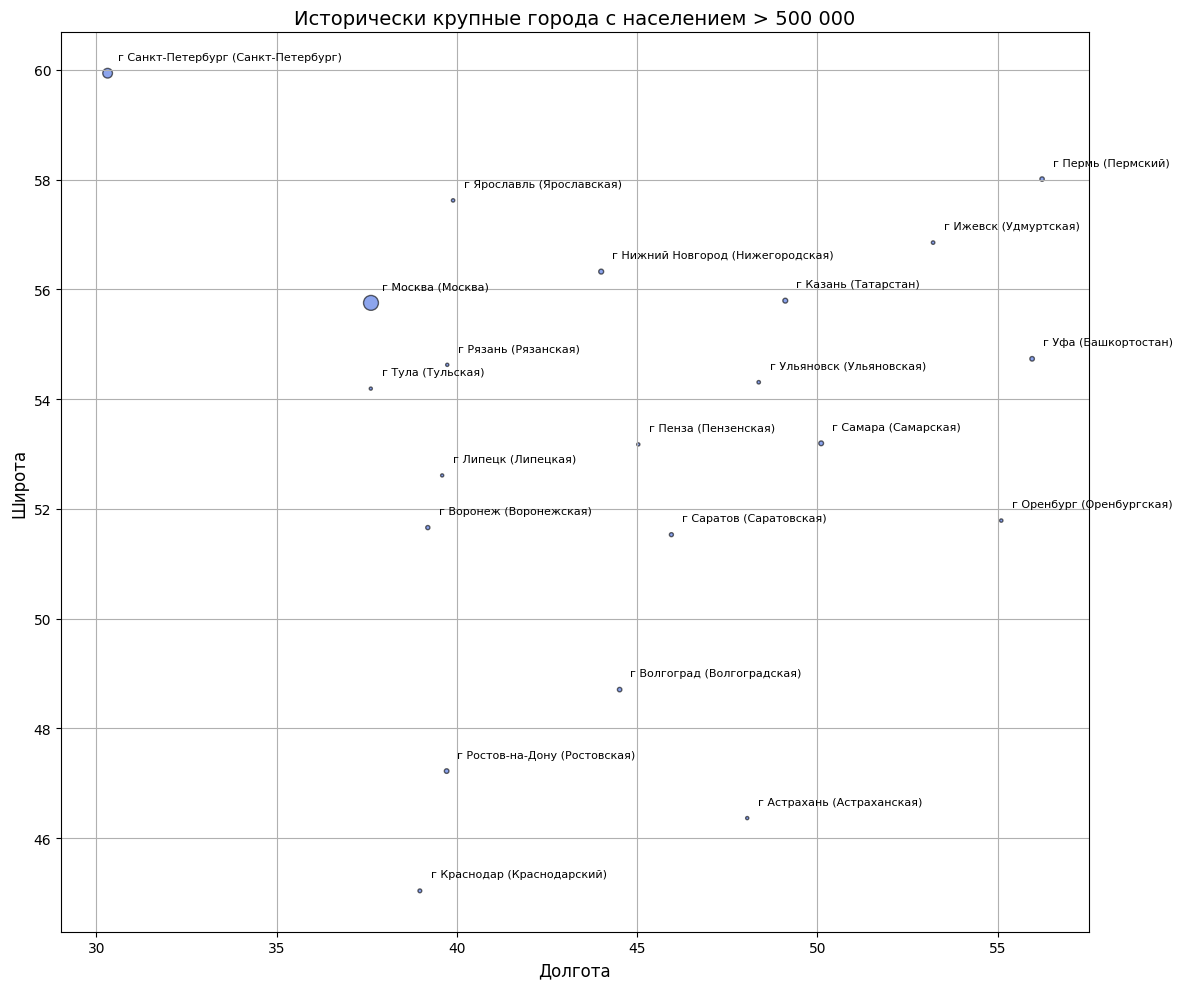

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

# Построение точек: население делим для масштабирования
plt.scatter(
    historic_large_cities["geo_lon"],
    historic_large_cities["geo_lat"],
    s=historic_large_cities["population"] / 100000,
    alpha=0.6,
    color='royalblue',
    edgecolors='k'
)

# Подписи городов
for _, row in historic_large_cities.iterrows():
    plt.text(
        row["geo_lon"] + 0.3,
        row["geo_lat"] + 0.3,
        f"{row['address']} ({row['region']})",
        fontsize=8,
        ha="left",
        va="center"
    )

# Подписи и оформление
plt.title("Исторически крупные города с населением > 500 000", fontsize=14)
plt.xlabel("Долгота", fontsize=12)
plt.ylabel("Широта", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


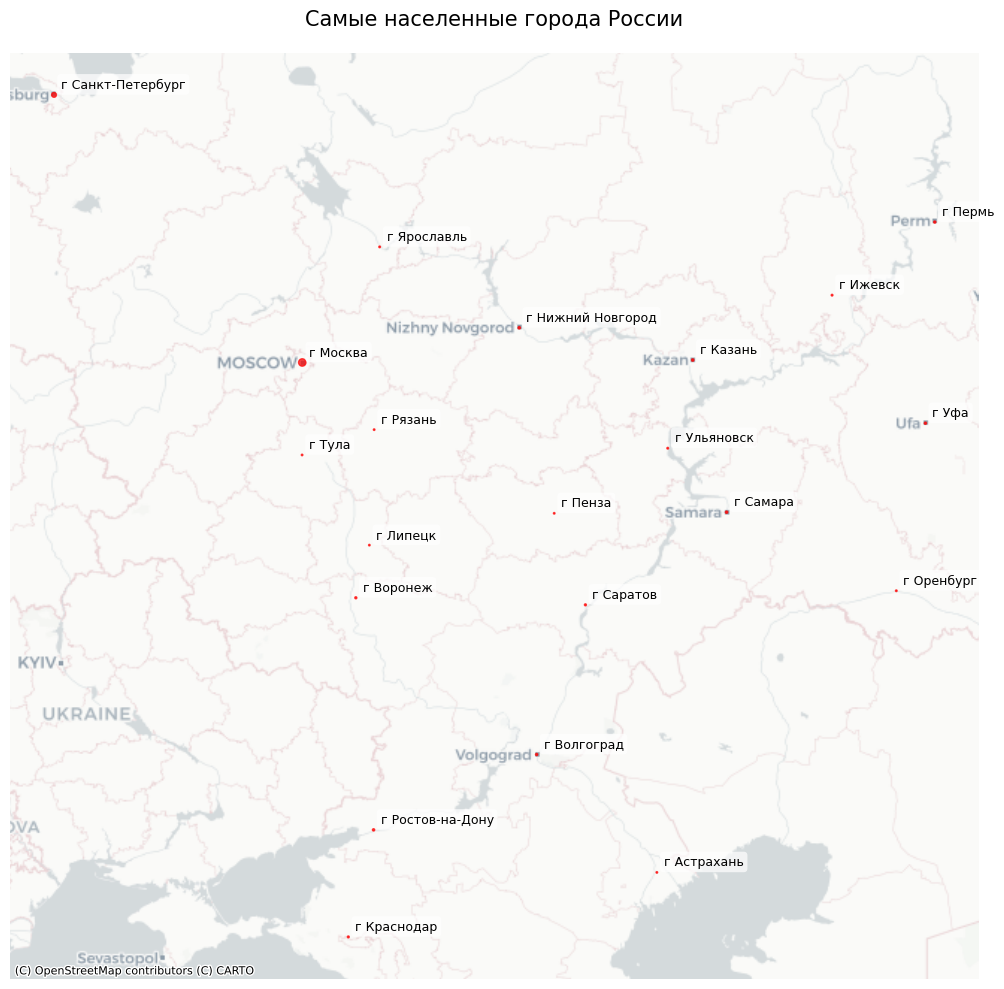

In [86]:
import contextily as ctx
import geopandas as gpd
from geopandas import GeoDataFrame
from shapely.geometry import Point
import matplotlib.pyplot as plt

# Создаем GeoDataFrame из наших данных
geometry: list[Point] = [
    Point(lng, lat) 
    for lng, lat in zip(
        historic_large_cities["geo_lon"], 
        historic_large_cities["geo_lat"]
    )
]
geodataframe = gpd.GeoDataFrame(historic_large_cities, geometry=geometry)

# Указываем исходную систему координат (широта/долгота)
geodataframe.set_crs(epsg=4326, inplace=True)

# Преобразуем в Web Mercator для корректного отображения карты
geodataframe: GeoDataFrame = geodataframe.to_crs(epsg=3857)

# Создаем график
plt.figure(figsize=(15, 10))
ax = plt.subplot(111)

# Отображаем города
geodataframe.plot(
    ax=ax, 
    marker="o", 
    color="red", 
    markersize=geodataframe["population"] / 400000, 
    alpha=0.7
)

# Подписи городов
for x, y, label in zip(geodataframe.geometry.x, geodataframe.geometry.y, geodataframe["address"]):
    ax.annotate(
        label, xy=(x, y), xytext=(5, 5), textcoords="offset points", 
        fontsize=9, color="black", 
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7)
    )

# Добавляем фон-карту
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Оформление
ax.set_axis_off()
plt.title(f"Самые населенные города России", fontsize=15, pad=20)
plt.tight_layout()
plt.show()


In [87]:
import networkx as nx
from geopy.distance import geodesic
import matplotlib.pyplot as plt

# Создаём пустой граф
G = nx.Graph()

# Добавляем узлы
for _, row in historic_large_cities.iterrows():
    G.add_node(
        row["address"],
        region=row["region"],
        country=row["country"],
        population=row["population"],
        year=row["foundation_year"],
        pos=(row["geo_lon"], row["geo_lat"])  # Для визуализации
    )

# Добавляем рёбра между всеми парами городов
cities = historic_large_cities[["address", "geo_lat", "geo_lon"]].values

for i in range(len(cities)):
    for j in range(i + 1, len(cities)):
        city1, lat1, lon1 = cities[i]
        city2, lat2, lon2 = cities[j]
        distance = geodesic((lat1, lon1), (lat2, lon2)).meters
        G.add_edge(city1, city2, weight=distance)

print(f"Граф построен: {G.number_of_nodes()} узлов, {G.number_of_edges()} рёбер")


Граф построен: 21 узлов, 210 рёбер


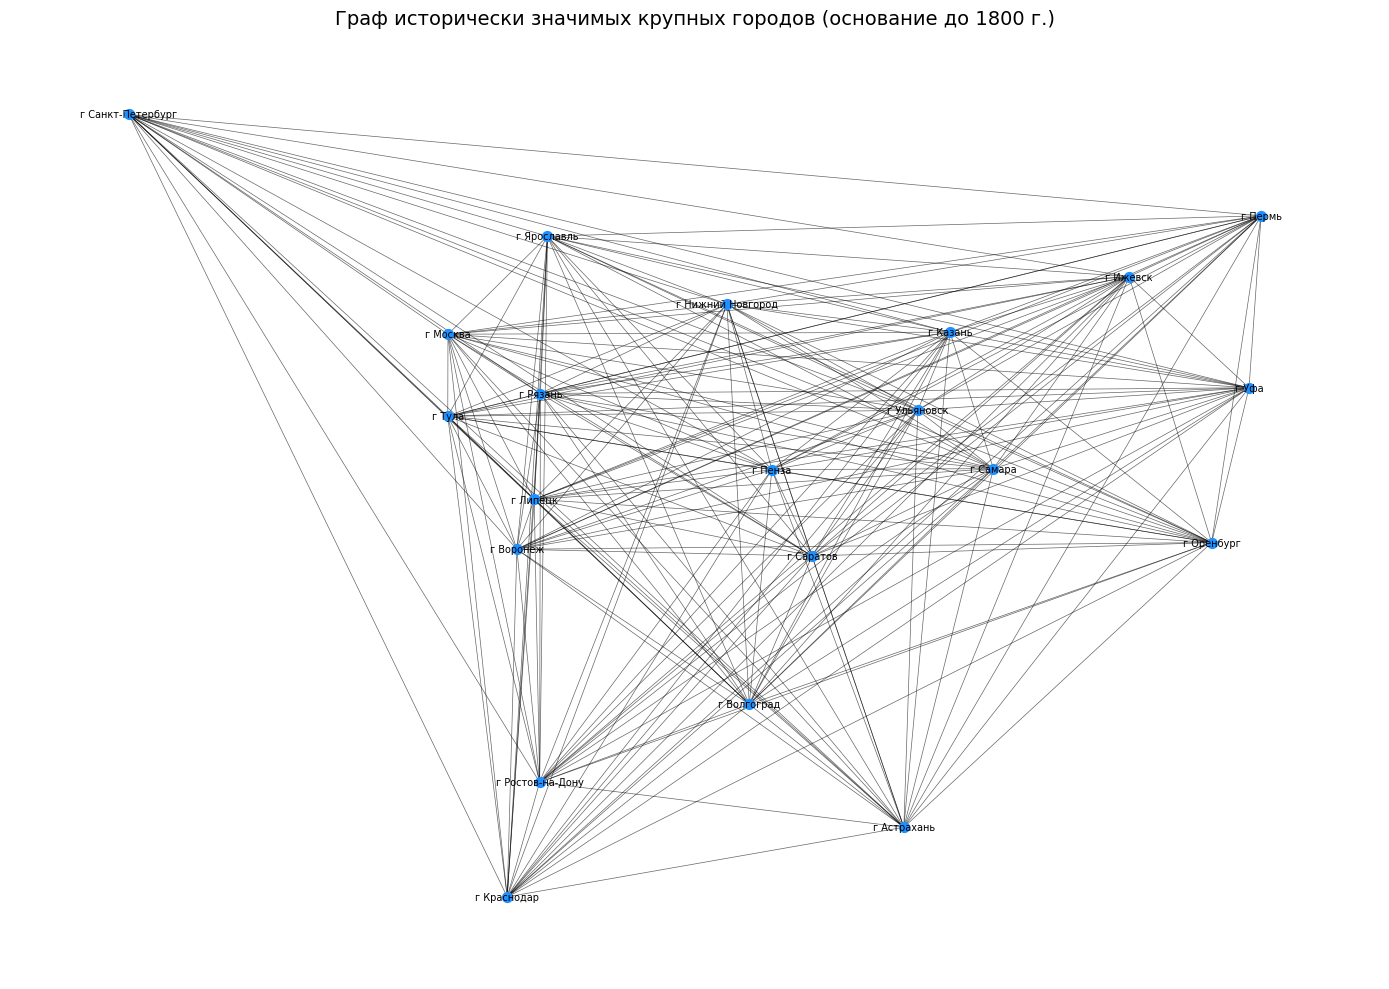

In [88]:
# Позиции узлов
pos = nx.get_node_attributes(G, "pos")

plt.figure(figsize=(14, 10))

# Визуализация
nx.draw_networkx_nodes(G, pos, node_size=50, node_color='dodgerblue')
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.6)

# Подписи городов (можно отключить при большом количестве)
nx.draw_networkx_labels(G, pos, font_size=7)

plt.title("Граф исторически значимых крупных городов (основание до 1800 г.)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


### Проектирование хромосом  

Для того, чтобы решить задачу генетическим алгоритмом нам нужно спроектировать хромосомы, используя кросинговер.  

> **Проектирование хромосом** - это один из важных и ключевых этапов разработки генетического алгоритма (ГА).  
*Хромосома* - это закодированное представление решения задачи. Она должна быть компактной, эффективной, позволять легко применять операторы кросинговера и мутации и в конечном итоге отражать возможные решения задачи или алгоритма. Иными словами Хромосома - это цепочка генов, то есть полное решение задачи. (В моей задаче - это маршрут или последовательность городов).  

> **Ген** – это минимальный элемент решения. В нашем случае - это город из списка городов. Каждое число есть определённый город. (п, 10 городов - список от 0 до 9).  

Основной особенностью является то, что в хромосоме каждый ген должен встречаться только один раз, ведь мы не можем посещать один город дважды в этой задаче.  

> **Фитнес-функция (Fitness Function)** — это ключевой компонент эволюционных алгоритмов (генетических алгоритмов, swarm optimization), который оценивает качество решения и определяет, насколько хорошо оно соответствует поставленной задаче. Простыми словами *фитнес-функция* — это "измеритель приспособленности" кандидата (решения) к заданным условиям. Чем выше значение фитнес-функции, тем лучше решение.  

*Фитнес-функция* будет оценивать, насколько хорош этот маршрут. В нашем случае – чем короче общее расстояние маршрута, тем лучше хромосома. Поэтому алгоритм будет стремиться находить хромосомы с минимальной длиной пути.

In [89]:
cities_list = list(G.nodes)
n = len(cities_list)
distance_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i != j:
            try:
                distance_matrix[i, j] = nx.shortest_path_length(
                    G, source=cities_list[i], target=cities_list[j], weight='weight'
                )
            except nx.NetworkXNoPath:
                distance_matrix[i, j] = 1e6  # Штраф

In [90]:
import random
import networkx as nx
from typing import List, Optional


# ===== Хромосома =====
class Chromosome:
    # ----- Инициализация решения -----
    def __init__(self, chromosome: List[int], distance_matrix: np.ndarray):
        if len(set(chromosome)) != len(chromosome):
            raise ValueError("Хромосома содержит дубликаты")
        self.chromosome = chromosome
        self.distance_matrix = distance_matrix
        self._total_distance: Optional[float] = None
        self._fitness: Optional[float] = None


    # ----- Проверка хромосомы на соответствие -----
    def valid_chromosome(self, chromosome: List[int], count_cities: int) -> bool:
        """ Проверка типа данных """
        if not isinstance(chromosome, list) or not all(isinstance(gene, int) for gene in chromosome):
            return False
            
        """ Проверка длины хромосомы """
        if len(chromosome) != count_cities:
            return False
        
        """ Проверка уникальности генов """
        if len(set(chromosome)) != count_cities:
            return False
        
        """ Проверка диапазона значений """
        if any(gene < 0 or gene >= count_cities for gene in chromosome):
            return False
            
        return True
    
    
    # ----- Вычисляем общую длину маршрута -----
    @property
    def _fitness_total_distance(self) -> float:
        if self._total_distance is None:
            self._total_distance = 0.0
            self._total_distance = sum(
                self.distance_matrix[self.chromosome[i], self.chromosome[(i + 1) % len(self.chromosome)]]
                for i in range(len(self.chromosome))
            )
        return self._total_distance
    
    
    # ----- Решаем и получаем значение fitness-функции -----
    @property
    def fitness(self) -> float:
        """Вычисляем как обратную величину к общей длине маршрута"""
        if self._fitness is None:
            self._fitness = 1 / self._fitness_total_distance
        return self._fitness
    

    # ----- Эволюция популяции -----
    @property
    def evaluate(self) -> float:
        return self.fitness
    
    
    # ----- Мутация -----
    def mutate(self):
        i, j = random.sample(range(len(self.chromosome)), 2)
        self.chromosome[i], self.chromosome[j] = self.chromosome[j], self.chromosome[i]
        self._fitness = None
        self._total_distance = None
    

    # ----- Представление решения в виде строки -----
    def __self__(self) -> str:
        return f"Маршрут: {self.chromosome} | Длина: {self._total_distance:.2f} км"

### Генерация начальной популяции  

Создадим популяцию случайным образом, где каждая хромосома индекс города, которая каждый раз переставляется, что обеспечивает разнообразие начальных решений.

In [91]:
# ====== Генерация начальной популяции =====
def generate_initial_population(population_size: int, count_cities: int) -> List[List[int]]:
    """Создает начальную популяцию случайных маршрутов."""
    population = []
    for _ in range(population_size):
        chromosome = list(range(count_cities))
        random.shuffle(chromosome)
        population.append(chromosome)
    return population

### Кроссинговер  

> **Кроссинговер** – это процесс обмена участками хромосом между родительскими особями для создания потомства. В данной задаче используется упорядоченный кроссовер (OX1), который сохраняет порядок городов из родительских маршрутов, избегая дублирований.  

Алгоритм работает следующим образом:

Выбирается случайный отрезок из первого родителя и копируется в потомка.
Оставшиеся города заполняются из второго родителя, начиная с конца выбранного отрезка, в порядке их появления, но исключая уже скопированные города. Этот метод позволяет комбинировать удачные участки маршрутов, сохраняя при этом допустимость решения (каждый город посещается ровно один раз).

In [92]:
# ===== Кроссинговер =====
def crossover(parent1: Chromosome, parent2: Chromosome) -> Chromosome:
    """Реализует упорядоченный одноточечный кроссинговер (OX1)."""
    size = len(parent1.chromosome)
    cut = random.randint(1, size - 2)
    head = parent1.chromosome[:cut]
    tail = [gene for gene in parent2.chromosome if gene not in head]
    return Chromosome(head + tail, parent1.distance_matrix)


# ===== Селекция (турнирный отбор) ======
def tournament_selection(population: List[Chromosome], tournament_size: int = 3) -> Chromosome:
    """Выбирает лучшую хромосому из случайной подгруппы."""
    contenders = random.sample(population, tournament_size)
    return max(contenders, key=lambda chrom: chrom.fitness)

### Оператор мутации

> **Мутация** - это оператор в эволюционных алгоритмах (например, генетических алгоритмах), который случайным образом изменяет часть решения (особи) для внесения разнообразия в популяцию и предотвращения преждевременной сходимости к субоптимальным решениям.  

Простыми словами это "случайное изменение" параметров решения, имитирующее биологические мутации. Она помогает алгоритму исследовать новые области пространства решений.  

*Мутация* вносит случайные изменения в хромосому, чтобы увеличить разнообразие популяции и избежать преждевременной сходимости к локальному оптимуму. В данном случае применяются два типа мутаций:  

* *Обменная мутация* (swap mutation) – случайно выбираются два гена (города) в хромосоме и меняются местами.  

* *Мутация перемешиванием* (scramble mutation) – случайный подотрезок хромосомы перемешивается, изменяя порядок городов внутри него.  

Мутация происходит с заданной вероятностью (mutation_rate), что позволяет контролировать баланс между исследованием новых решений и сохранением уже найденных хороших вариантов.

In [93]:
# ===== Обменная мутация =====
def swap_mutate(chromosome: List[int], mutation_rate: float) -> Chromosome:
    """Случайно меняет местами 2 города"""
    if np.random.random() < mutation_rate:
        genes = chromosome.chromosome
        idx1, idx2 = np.random.choice(len(genes), 2, replace=False)
        genes[idx1], genes[idx2] = genes[idx2], genes[idx1]
    return chromosome


# ===== Мутация перемешиванием =====
def scramble_mutation(chromosome: List[int], mutation_rate: float) -> Chromosome:
    """Мутация "перемешиванием" случайного отрезка"""
    if np.random.random() < mutation_rate:
        size: int = len(chromosome)
        start, end = sorted(np.random.randint(0, size, 2))
        segment: List[int] = chromosome[start:end]
        np.random.shuffle(segment)
        chromosome[start:end] = segment
    return chromosome

### Генетический алгоритм   

> **Генетический алгоритм (ГА)** — это эволюционный метод оптимизации и поиска решений, основанный на принципах естественного отбора и генетики. Он используется для решения сложных задач, где традиционные методы неэффективны.  

*Ключевые этапы генетического алгоритма*
1. Инициализация популяции (Создается начальная популяция)
* Создаётся набор случайных решений («особей»).
* Каждая особь представляет собой закодированное решение (битовую строку, вектор чисел).
2. Оценка приспособленности (Fitness Function)
* Каждая особь оценивается с помощью фитнес-функции, которая определяет её качество (коммивояжёр - длина маршрута).
3. Селекция (Отбор)
* Выбираются лучшие особи для «размножения».
* Методы: Рулетка (вероятность выбора пропорциональна fitness). Турнирный отбор (случайная выборка + выбор лучшего).
4. Скрещивание (Crossover)
* Родительские особи обмениваются частями своих решений.
Одноточечное скрещивание: Родитель1: [A,B,C,D], Родитель2: [1,2,3,4] → Потомок: [A,B,3,4]. Двухточечное: Потомок: [A,2,3,D]
5. Мутация
* Случайное изменение части решения для разнообразия. Пример: [A,B,C,D] → [A,X,C,D] (мутировал 2-й ген).
6. Замена поколений
* Новое поколение заменяет старое (или частично).
* Стратегии: Полная замена (все родители умирают). Элитизм (лучшие особи сохраняются).
7. Критерии остановки (Алгоритм завершается при...)
* Достижении max итераций.
* Нахождении решения с достаточным fitness.
* Отсутствии улучшений несколько поколений.  

**Основной эволюционный цикл** Для каждого поколения выполняются следующие шаги:

1. Оценка приспособленности Для каждой хромосомы вычисляется фитнес-функция как обратная величина к длине маршрута. Это делает более короткие маршруты более предпочтительными.
2. Отбор элиты Лучшие elite_size решений переходят в следующее поколение без изменений, сохраняя уже найденные хорошие варианты.
3. Формирование нового поколения Популяция дополняется потомками, созданными с помощью: Турнирного отбора (случайно выбираются несколько особей), Упорядоченного кроссовера (комбинация родительских маршрутов) и Мутаций - случайные изменения (обмен городов или перемешивание).

In [94]:
from typing import Callable, List

# ===== Основной цикл Генетического Алгоритма ----
def genetic_algorithm(cities: pd.DataFrame, generations: int = 400, mutation_rate: float = 0.01, population_size: int = 100,
    elite_size: int = 20, crossover_function: Callable = crossover, mutation_function: Callable = swap_mutate) -> Chromosome:
    """Запускает генетический алгоритм."""
    
    # Создание матрицы расстояний
    fitness_history = []
    coords = cities[["geo_lat", "geo_lon"]].values
    distance_matrix = np.zeros((len(coords), len(coords)))
    for i in range(len(coords)):
        for j in range(len(coords)):
            if i != j:
                distance_matrix[i][j] = haversine_distance(coords[i], coords[j])
    
    # Генерация начальной популяции как объектов Chromosome
    population: List[Chromosome] = [
        Chromosome(chromo, distance_matrix)
        for chromo in generate_initial_population(population_size, len(cities))
    ]

    # Основной цикл эволюции
    for generation in range(generations):
        # Сортировка по приспособленности
        population.sort(key=lambda x: x.fitness, reverse=True)

        # Элита
        new_population: List[Chromosome] = population[:elite_size]

        # Генерация потомков
        while len(new_population) < population_size:
            parent1 = tournament_selection(population, tournament_size=3)
            parent2 = tournament_selection(population, tournament_size=3)
            
            child = crossover_function(parent1, parent2)

            if random.random() < mutation_rate:
                mutation_function(child, mutation_rate)

            new_population.append(child)

        population = new_population
        best = population[0]
        fitness_history.append(1 / best.fitness)  # Длина маршрута в км или м
        print(f"Поколение {generation + 1} | Лучшая длина маршрута: {1 / best.fitness:.2f} км")

    return population[0], fitness_history



def haversine_distance(coordinate1: np.ndarray, coordinate2: np.ndarray) -> float:
    """Вычисляет расстояние между двумя точками на сфере (в км) по формуле гаверсинусов."""
    lat1, lon1 = coordinate1
    lat2, lon2 = coordinate2
    
    # Конвертация градусов в радианы
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Разницы координат
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Формула гаверсинусов
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Радиус Земли в километрах
    r = 6371
    return c * r

In [95]:
# Запуск Генетического Алгоритма
best, fitness_history = genetic_algorithm(
    historic_large_cities,
    population_size=100,
    elite_size=20,
    mutation_rate=0.05,
    generations=500,
    crossover_function=crossover,
    mutation_function=swap_mutate
)

print(f"Лучший маршрут: {best.chromosome}")
print(f"Общая длина маршрута: {1 / best.fitness:.2f} км")

Поколение 1 | Лучшая длина маршрута: 13695.95 км
Поколение 2 | Лучшая длина маршрута: 13415.83 км
Поколение 3 | Лучшая длина маршрута: 12720.14 км
Поколение 4 | Лучшая длина маршрута: 12303.54 км
Поколение 5 | Лучшая длина маршрута: 11830.66 км
Поколение 6 | Лучшая длина маршрута: 11138.13 км
Поколение 7 | Лучшая длина маршрута: 11138.13 км
Поколение 8 | Лучшая длина маршрута: 11138.13 км
Поколение 9 | Лучшая длина маршрута: 10527.06 км
Поколение 10 | Лучшая длина маршрута: 10527.06 км
Поколение 11 | Лучшая длина маршрута: 10255.78 км
Поколение 12 | Лучшая длина маршрута: 10255.78 км
Поколение 13 | Лучшая длина маршрута: 10089.29 км
Поколение 14 | Лучшая длина маршрута: 10089.29 км
Поколение 15 | Лучшая длина маршрута: 10089.29 км
Поколение 16 | Лучшая длина маршрута: 9940.90 км
Поколение 17 | Лучшая длина маршрута: 9940.90 км
Поколение 18 | Лучшая длина маршрута: 9940.90 км
Поколение 19 | Лучшая длина маршрута: 9940.90 км
Поколение 20 | Лучшая длина маршрута: 9940.90 км
Поколение 21 |

### Визуализация результата

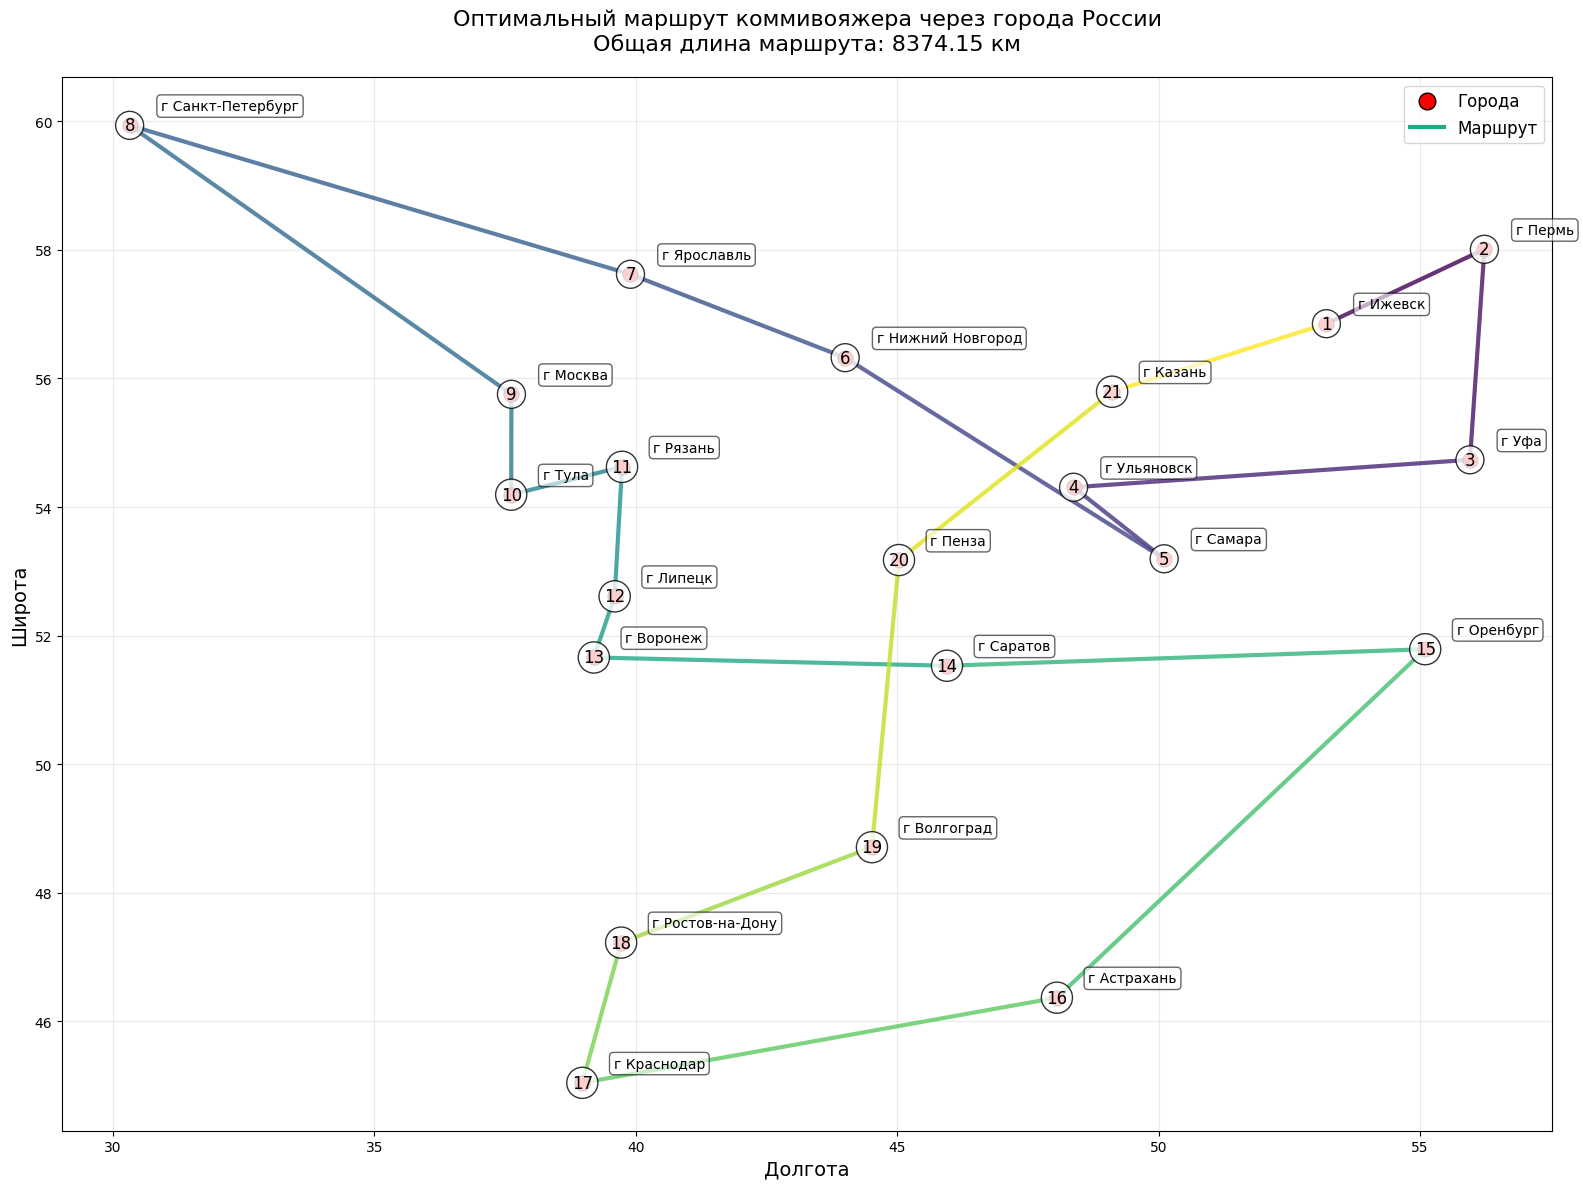

In [96]:
import matplotlib.cm as cm

plt.figure(figsize=(16, 12))

# Города с тенью для объёма
plt.scatter(
    historic_large_cities["geo_lon"], 
    historic_large_cities["geo_lat"], 
    c="red", s=120, edgecolors='black', linewidth=0.7, alpha=0.9, zorder=5
)

# Цветовой градиент для маршрута (от начала к концу)
route_order = best.chromosome + [best.chromosome[0]]
route_lng = [historic_large_cities.iloc[i]["geo_lon"] for i in route_order]
route_lat = [historic_large_cities.iloc[i]["geo_lat"] for i in route_order]

colors = cm.viridis(np.linspace(0, 1, len(route_order)-1))
for i in range(len(route_order)-1):
    plt.plot(
        route_lng[i:i+2], route_lat[i:i+2], 
        color=colors[i], linewidth=3, alpha=0.8, zorder=4
    )

# Номера и подписи городов с фоном
for i, city_idx in enumerate(best.chromosome):
    city = historic_large_cities.iloc[city_idx]

    plt.text(
        city["geo_lon"], city["geo_lat"], str(i+1),
        fontsize=12, ha="center", va="center",
        bbox=dict(facecolor="white", alpha=0.8, boxstyle="circle"), zorder=6
    )

    plt.text(
        city["geo_lon"] + 0.6, city["geo_lat"] + 0.3,
        f'{city["address"]}',
        fontsize=10, ha="left", va="center",
        bbox=dict(facecolor="white", alpha=0.6, boxstyle="round,pad=0.3"), zorder=6
    )

# Настройки графика
plt.title(
    "Оптимальный маршрут коммивояжера через города России\n"
    f"Общая длина маршрута: {best._total_distance:.2f} км",
    fontsize=16, pad=20
)
plt.xlabel("Долгота", fontsize=14)
plt.ylabel("Широта", fontsize=14)
plt.grid(alpha=0.25)
plt.tight_layout()

# Легенда с кастомными маркерами
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Города', markerfacecolor='red', markersize=12, markeredgecolor='black'),
    Line2D([0], [0], color=cm.viridis(0.6), lw=3, label='Маршрут')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.show()


### Визуализация результата на карте

In [97]:
import folium


# Создаем базовую карту центрированную на Европе
m = folium.Map(location=[50.0, 15.0], zoom_start=4, tiles="CartoDB positron")

# Добавляем маркеры для каждого города
for idx, row in historic_large_cities.iterrows():
    pop_text: str = f"{row["address"]}, {row["region"]}<br>Население: {int(row["population"]):,}"
    folium.CircleMarker(
        location=[row["geo_lat"], row["geo_lon"]],
        radius=row["population"]/3000000,
        popup=pop_text,
        color="#3186cc",
        fill=True,
        fill_color="#3186cc"
    ).add_to(m)

display(m)

In [98]:
import folium
from branca.colormap import linear


# Создаем карту центрированную на средних координатах городов
avg_lat = historic_large_cities["geo_lat"].mean()
avg_lng = historic_large_cities["geo_lon"].mean()
m = folium.Map(location=[avg_lat, avg_lng], zoom_start=5, tiles="CartoDB positron")

# Создаем цветовую шкалу для маршрута
colormap = linear.PuRd_09.scale(0, len(best.chromosome)-1)

# Добавляем маркеры для каждого города
for idx, row in historic_large_cities.iterrows():
    folium.CircleMarker(
        location=[row["geo_lat"], row["geo_lon"]],
        radius=5,
        popup=f"{row["address"]}, {row["region"]}",
        color="#3186cc",
        fill=True,
        fill_color="#3186cc"
    ).add_to(m)

# Добавляем линии маршрута
route_coords = []
for i, city_idx in enumerate(best.chromosome):
    city = historic_large_cities.iloc[city_idx]
    route_coords.append([city["geo_lat"], city["geo_lon"]])
    
    # Добавляем номер посещения
    folium.Marker(
        location=[city["geo_lat"], city["geo_lon"]],
        icon=folium.DivIcon(
            icon_size=(30,30),
            icon_anchor=(15,15),
            html=f"<div style='font-size: 10pt; color: white; background: #3186cc; border-radius: 50%; width: 20px; height: 20px; display: flex; align-items: center; justify-content: center;'>{i+1}</div>"
        )
    ).add_to(m)

# Замыкаем маршрут (возвращаемся в начальный город)
route_coords.append(route_coords[0])

# Добавляем линию маршрута с цветовой градиентной шкалой
for i in range(len(route_coords)-1):
    folium.PolyLine(
        locations=[route_coords[i], route_coords[i+1]],
        color=colormap(i),
        weight=3,
        opacity=0.8
    ).add_to(m)

# Добавляем легенду с цветовой шкалой
colormap.caption = f"Оптимальный маршрут коммивояжера через городов Европы"
colormap.add_to(m)

display(m)

### Использование библиотеки PyGAD

In [99]:
import pygad
import numpy as np

def order_crossover(parents: np.ndarray, offspring_size: tuple, ga_instance: pygad.GA) -> np.ndarray:
    offspring = []
    idx = 0
    
    while len(offspring) < offspring_size[0]:
        parent1 = parents[idx % parents.shape[0], :].copy()
        parent2 = parents[(idx + 1) % parents.shape[0], :].copy()
        
        size = parent1.shape[0]
        start, end = sorted(np.random.choice(range(size), 2, replace=False))
        
        child1 = -1 * np.ones(size, dtype=int)
        child1[start:end] = parent1[start:end]
        
        ptr = end
        for gene in np.concatenate([parent2[end:], parent2[:end]]):
            if gene not in child1[start:end]:
                if ptr >= size:
                    ptr = 0
                child1[ptr] = gene
                ptr += 1
        
        offspring.append(child1)
        idx += 1
    
    return np.array(offspring)


def swap_mutation(offspring: np.ndarray, ga_instance: pygad.GA) -> np.ndarray:
    for chromosome_idx in range(offspring.shape[0]):
        if np.random.random() < ga_instance.mutation_probability:
            idx1, idx2 = np.random.choice(offspring.shape[1], 2, replace=False)
            offspring[chromosome_idx, idx1], offspring[chromosome_idx, idx2] = \
                offspring[chromosome_idx, idx2], offspring[chromosome_idx, idx1]
    return offspring


def fitness_func(ga_instance: pygad.GA, solution: np.ndarray, solution_idx: int) -> float:
    # Проверка на уникальность генов
    if len(set(solution)) != len(solution):
        return 0.0  # Возвращаем очень плохое значение фитнеса для невалидных решений
    
    total_distance = 0.0
    for i in range(len(solution)):
        j: int = (i + 1) % len(solution)
        city_i = int(solution[i])
        city_j = int(solution[j])
        total_distance += haversine_distance(coords[city_i], coords[city_j])
    
    return 1 / total_distance


# Подготовка данных
coords = historic_large_cities[["geo_lat", "geo_lon"]].values
num_cities: int = len(coords)

ga_instance = pygad.GA(
    num_generations=500,
    num_parents_mating=20,
    fitness_func=fitness_func,
    sol_per_pop=100,
    num_genes=num_cities,
    gene_type=int,
    init_range_low=0,
    init_range_high=num_cities-1,
    crossover_type=order_crossover,
    mutation_type=swap_mutation,
    mutation_probability=0.05,
    suppress_warnings=True,
    allow_duplicate_genes=False,
    gene_space=list(range(num_cities))
)

# Запуск алгоритма
ga_instance.run()

# Получение лучшего решения
best_solution_pygad = ga_instance.best_solution()

# Преобразование результата в наш формат
best_chromosome = [int(gene) for gene in best_solution_pygad[0]]
distance_matrix = np.zeros((num_cities, num_cities))
for i in range(num_cities):
    for j in range(num_cities):
        if i != j:
            distance_matrix[i][j] = haversine_distance(coords[i], coords[j])

tsp_solution = Chromosome(best_chromosome, distance_matrix)

# Вывод результатов
print("\nРезультат работы PyGAD:")
print(f"Fitness: {best_solution_pygad[1]}")
print(tsp_solution)


Результат работы PyGAD:
Fitness: 0.00013335409464045083


### Визуализация результата PyGAD

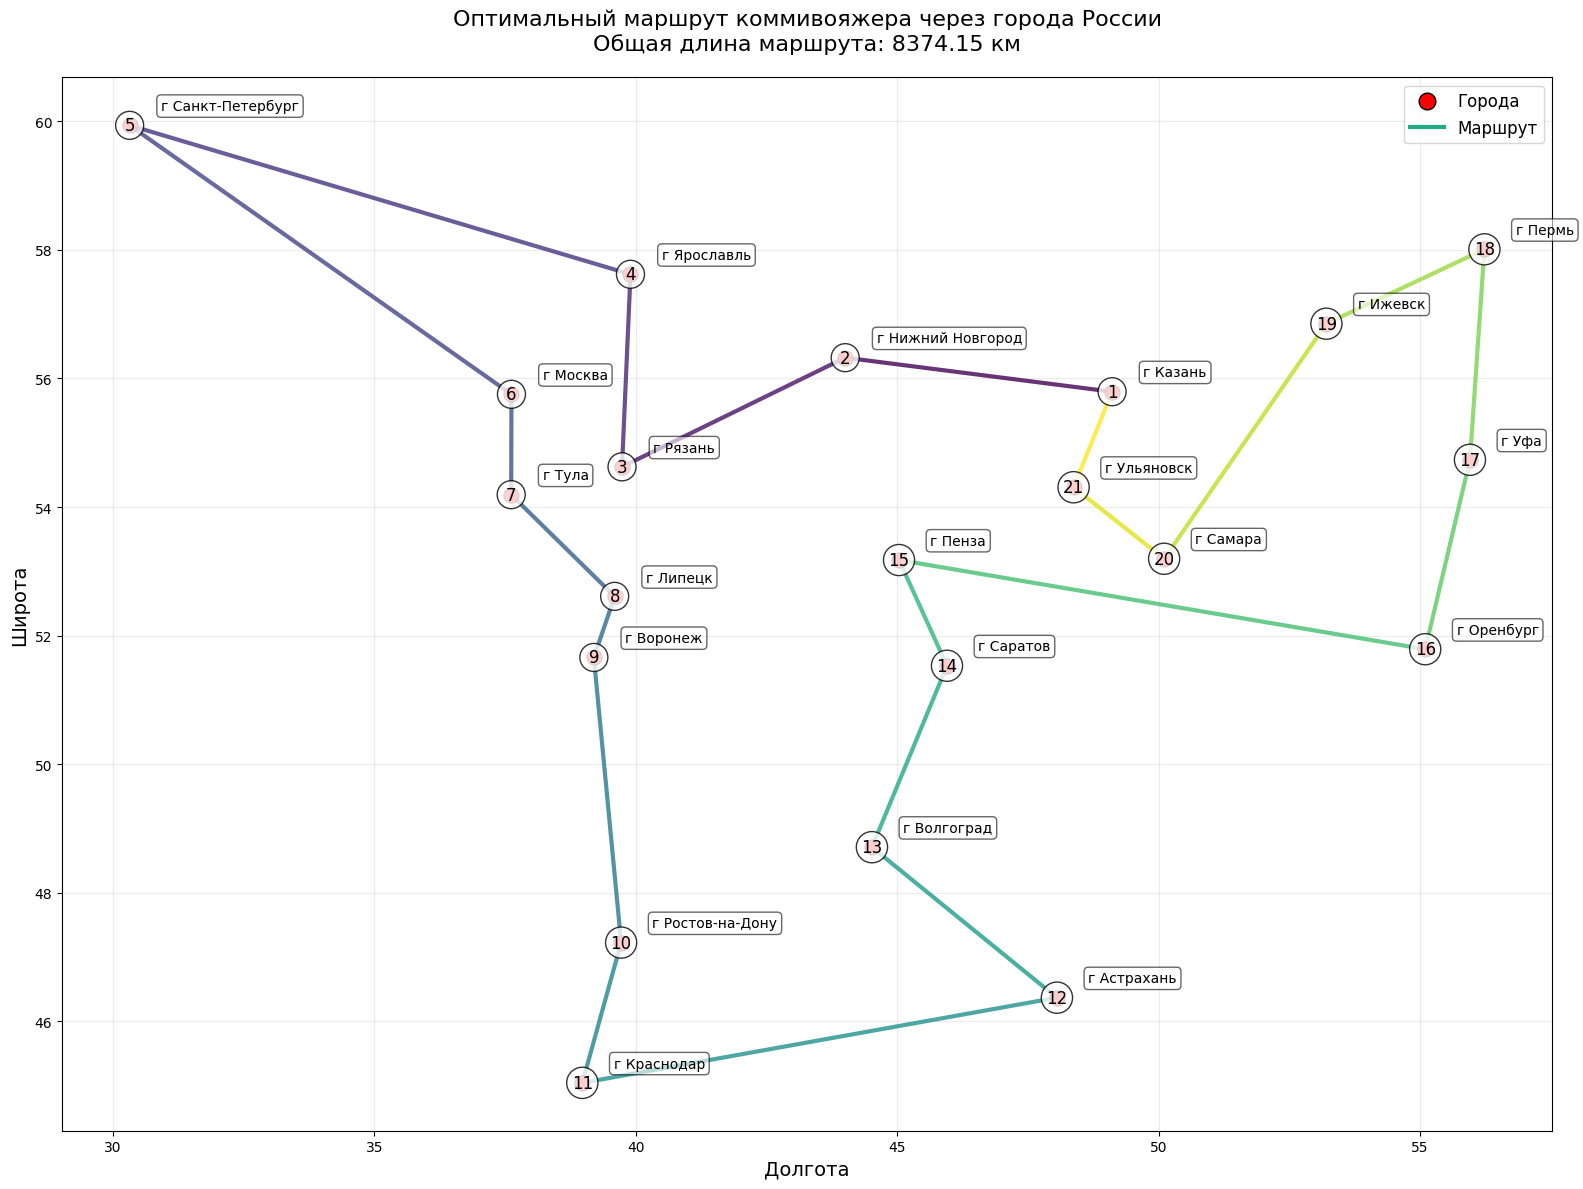

In [100]:
import matplotlib.cm as cm

plt.figure(figsize=(16, 12))

# Города с тенью для объёма
plt.scatter(
    historic_large_cities["geo_lon"], 
    historic_large_cities["geo_lat"], 
    c="red", s=120, edgecolors='black', linewidth=0.7, alpha=0.9, zorder=5
)

# Цветовой градиент для маршрута (от начала к концу)
route_order = tsp_solution.chromosome + [tsp_solution.chromosome[0]]
route_lng = [historic_large_cities.iloc[i]["geo_lon"] for i in route_order]
route_lat = [historic_large_cities.iloc[i]["geo_lat"] for i in route_order]

colors = cm.viridis(np.linspace(0, 1, len(route_order)-1))
for i in range(len(route_order)-1):
    plt.plot(
        route_lng[i:i+2], route_lat[i:i+2], 
        color=colors[i], linewidth=3, alpha=0.8, zorder=4
    )

# Номера и подписи городов с фоном
for i, city_idx in enumerate(tsp_solution.chromosome):
    city = historic_large_cities.iloc[city_idx]

    plt.text(
        city["geo_lon"], city["geo_lat"], str(i+1),
        fontsize=12, ha="center", va="center",
        bbox=dict(facecolor="white", alpha=0.8, boxstyle="circle"), zorder=6
    )

    plt.text(
        city["geo_lon"] + 0.6, city["geo_lat"] + 0.3,
        f'{city["address"]}',
        fontsize=10, ha="left", va="center",
        bbox=dict(facecolor="white", alpha=0.6, boxstyle="round,pad=0.3"), zorder=6
    )

# Настройки графика
plt.title(
    "Оптимальный маршрут коммивояжера через города России\n"
    f"Общая длина маршрута: {best._total_distance:.2f} км",
    fontsize=16, pad=20
)
plt.xlabel("Долгота", fontsize=14)
plt.ylabel("Широта", fontsize=14)
plt.grid(alpha=0.25)
plt.tight_layout()

# Легенда с кастомными маркерами
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Города', markerfacecolor='red', markersize=12, markeredgecolor='black'),
    Line2D([0], [0], color=cm.viridis(0.6), lw=3, label='Маршрут')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.show()


### Интерактивная визуализация PyGAD на карте мира

In [101]:
# Создаем карту центрированную на средних координатах городов
avg_lat = historic_large_cities["geo_lat"].mean()
avg_lng = historic_large_cities["geo_lon"].mean()
m = folium.Map(location=[avg_lat, avg_lng], zoom_start=5, tiles="CartoDB positron")

# Создаем цветовую шкалу для маршрута
colormap = linear.PuRd_09.scale(0, len(tsp_solution.chromosome)-1)

# Добавляем маркеры для каждого города
for idx, row in historic_large_cities.iterrows():
    folium.CircleMarker(
        location=[row["geo_lat"], row["geo_lon"]],
        radius=5,
        popup=f"{row["city"]}, {row["country"]}",
        color="#3186cc",
        fill=True,
        fill_color="#3186cc"
    ).add_to(m)

# Добавляем линии маршрута
route_coords = []
for i, city_idx in enumerate(tsp_solution.chromosome):
    city = historic_large_cities.iloc[city_idx]
    route_coords.append([city["geo_lat"], city["geo_lon"]])
    
    # Добавляем номер посещения
    folium.Marker(
        location=[city["geo_lat"], city["geo_lon"]],
        icon=folium.DivIcon(
            icon_size=(30,30),
            icon_anchor=(15,15),
            html=f"<div style='font-size: 10pt; color: white; background: #3186cc; border-radius: 50%; width: 20px; height: 20px; display: flex; align-items: center; justify-content: center;'>{i+1}</div>"
        )
    ).add_to(m)

# Замыкаем маршрут (возвращаемся в начальный город)
route_coords.append(route_coords[0])

# Добавляем линию маршрута с цветовой градиентной шкалой
for i in range(len(route_coords)-1):
    folium.PolyLine(
        locations=[route_coords[i], route_coords[i+1]],
        color=colormap(i),
        weight=3,
        opacity=0.8
    ).add_to(m)

# Добавляем легенду с цветовой шкалой
colormap.caption = f"Оптимальный маршрут коммивояжера через городов России"
colormap.add_to(m)

display(m)

### Путь в строке GA

In [102]:
def print_city_route(best_chromosome, city_df):
    """Печатает маршрут обхода городов с направлением.
        best_chromosome: список индексов городов (например, best.chromosome)
        city_df: DataFrame с данными городов (например, historic_large_cities)
    """
    print("Маршрут коммивояжера:\n")
    
    for i in range(len(best_chromosome)):
        city_idx = best_chromosome[i]
        city_name = city_df.iloc[city_idx]["address"]
        print(f"{i + 1}. {city_name}")
        if i < len(best_chromosome) - 1:
            print("↓")
    
    # Возвращение в начальный город
    start_city = city_df.iloc[best_chromosome[0]]["address"]
    print("↓")
    print(f"{len(best_chromosome) + 1}. {start_city} (возвращение в начальный город)")

print_city_route(best.chromosome, historic_large_cities)

Маршрут коммивояжера:

1. г Ижевск
↓
2. г Пермь
↓
3. г Уфа
↓
4. г Ульяновск
↓
5. г Самара
↓
6. г Нижний Новгород
↓
7. г Ярославль
↓
8. г Санкт-Петербург
↓
9. г Москва
↓
10. г Тула
↓
11. г Рязань
↓
12. г Липецк
↓
13. г Воронеж
↓
14. г Саратов
↓
15. г Оренбург
↓
16. г Астрахань
↓
17. г Краснодар
↓
18. г Ростов-на-Дону
↓
19. г Волгоград
↓
20. г Пенза
↓
21. г Казань
↓
22. г Ижевск (возвращение в начальный город)


### Путь в строке PyGad

In [103]:
print_city_route(tsp_solution.chromosome, historic_large_cities)

Маршрут коммивояжера:

1. г Казань
↓
2. г Нижний Новгород
↓
3. г Рязань
↓
4. г Ярославль
↓
5. г Санкт-Петербург
↓
6. г Москва
↓
7. г Тула
↓
8. г Липецк
↓
9. г Воронеж
↓
10. г Ростов-на-Дону
↓
11. г Краснодар
↓
12. г Астрахань
↓
13. г Волгоград
↓
14. г Саратов
↓
15. г Пенза
↓
16. г Оренбург
↓
17. г Уфа
↓
18. г Пермь
↓
19. г Ижевск
↓
20. г Самара
↓
21. г Ульяновск
↓
22. г Казань (возвращение в начальный город)


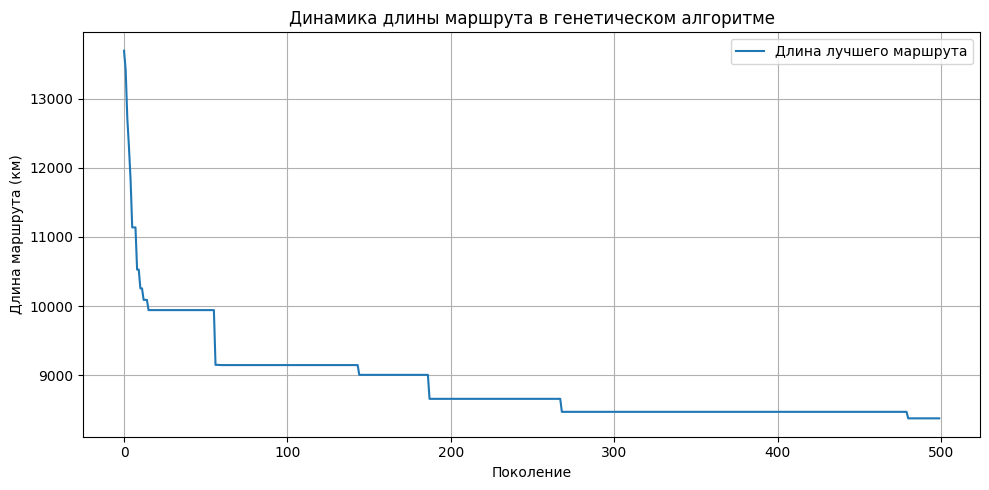

In [104]:
plt.figure(figsize=(10, 5))
plt.plot(fitness_history, label="Длина лучшего маршрута")
plt.xlabel("Поколение")
plt.ylabel("Длина маршрута (км)")
plt.title("Динамика длины маршрута в генетическом алгоритме")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
